<a href="https://colab.research.google.com/github/AlxScottt/undergrad_ml_assignments/blob/main/05_assignment_glm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MY name... Alexander... Scott!!!

My computing id... is... hmn7zu!

Soruces: I used ChatGPT to help me code and debug. Grammerly to help make my words understanble, and the wonderfull google to google concepts which confsued.

# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

Ok so like basically, the magical things (the things said above) are used because they allow you to do more super cool stuff with data that is not just linear. GLM let you have link fuctions for differnt types of differnt types of data (binary or counts). so like big picture, you can do more complex data anyalsis but apply it to non-linaer problems.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

Because in both of those your doing cool math for probobolaties, and since there both being applied to logistic regresion it works. (Math works for regression!)

3. True or false, and explain: Logistic regression is a linear model.

True, google says there is a caviat because it uses a sigmoi function to map its output. But like you apply it to linear paramters, so its techinaly a linear model!

4. True or false, and explain: Logistic regression cannot be used for classification.

False, thats like fr it use. thats what u do!

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

No, its like the wierd thing where its not fr the change. He stressed this in class its like not actualy showign that. Log-odds?

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False. Your data still gotta be understanble and the model will flop. IF you dident do the engineering for the nonlinear features it might underfit.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False. If you think about this logically why would he teach it in the first place? Its like if you had a rabbit that wanted carrot cake, but you started telling it about lemon cake? Why are you telling it about lemon cake? Im a rabbit. give me the cake.

It all depends on the context of the problem and the result you are trying to understand/make. Use the correct tool in classifaction or contiuonus data.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [9]:
import pandas as pd

df = pd.read_csv("data.csv", sep=";") #get the data!!

In [11]:
#1 contuiend get the right data
cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]

df = df[cols]

In [12]:
#deal with the missing stuff
df.isna().sum() #but theres none so we good !!

,0
Debtor,0
Tuition fees up to date,0
Scholarship holder,0
Age at enrollment,0
Curricular units 1st sem (approved),0
Target,0


In [13]:
#make the target 1
df["dropout"] = df["Target"].apply(lambda x: 1 if x == "Dropout" else 0)

In [14]:
#2 logistic regression time
from sklearn.linear_model import LogisticRegression

X = df[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment"
]]

y = df["dropout"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000)

In [15]:
pd.Series(model.coef_[0], index=X.columns)

,0
Debtor,0.530625
Tuition fees up to date,-2.556542
Scholarship holder,-1.227442
Age at enrollment,0.049925


#2
If your tution feets up to date, and you are  a scholarship holfer you are less likey to drop out! If you are a debtor though, or old you might be cooked.

In [16]:
#3 time
df["pred_dropout"] = model.predict_proba(X)[:, 1]

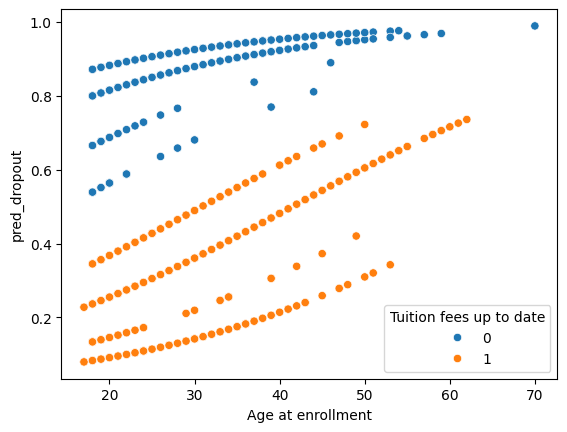

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="Age at enrollment",
    y="pred_dropout",
    hue="Tuition fees up to date"
)
plt.show()

In [18]:
df.groupby("Tuition fees up to date")["pred_dropout"].mean()

,pred_dropout
Tuition fees up to date,
0,0.860675
1,0.248090


#3
If they arent up to date, it goes to 86%, if they are 24%. If you are yuonger, it seems to be lower.

In [19]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

confusion_matrix(y, y_pred)
accuracy_score(y, y_pred)

0.7619801084990958

#4
its 76.19%

In [20]:
#5
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X, y)

df["lin_pred"] = lin_model.predict(X)

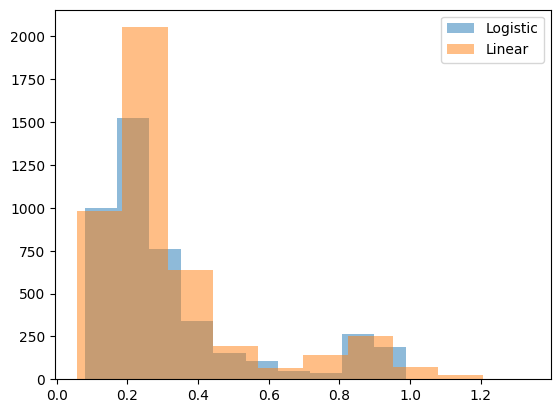

In [21]:
#5 contuined
plt.hist(df["pred_dropout"], alpha=0.5, label="Logistic")
plt.hist(df["lin_pred"], alpha=0.5, label="Linear")
plt.legend()
plt.show()

#5
Pretty simlir ish, but linear seems to be a bit overdramtic. Logsitc is the queen it seems.


#6
it seems the most at risk students are those who are not up to date on tution and no schoalrship. Some intervetations could be more finical aid, increased goverment funding, or more lax payment plans with lower interest rates.

In [22]:
#7
X_multi = df[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]

y_multi = df["Target"]

multi_model = LogisticRegression(multi_class="multinomial", max_iter=1000)
multi_model.fit(X_multi, y_multi)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [23]:
y_pred_multi = multi_model.predict(X_multi)

confusion_matrix(y_multi, y_pred_multi)

array([[1054,    0,  367],
       [ 280,    0,  514],
       [ 146,    0, 2063]])

#7
It sucks at indetfiyng class one and does not do it at all, although overall accuary is high, this faliure is imporant! probaly is underrepsented in the data. (It does not find them all)

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [24]:
#1
import pandas as pd

df = pd.read_csv("cirrhosis.csv")

cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
df = df[cols]

In [25]:
#1 contuiend queen
df.isna().sum() #only drug is missig

,0
Bilirubin,0
Edema,0
Drug,106
Stage,6
Status,0


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?